# 1.Installing Required Python Libraries

In [1]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install torch torchvision
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4

# 2.Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report

import pennylane as qml

# 3.Define Dataset Path and Hyperparameters

In [3]:
DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")
VAL_DIR = os.path.join(DATASET_PATH, "val")

BATCH_SIZE = 32
IMAGE_SIZE = 128
EPOCHS = 5
LR = 0.001

NUM_QUBITS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


# 4.Dataset Loading and Preprocessing

In [4]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


# 5. a)Data class prediction

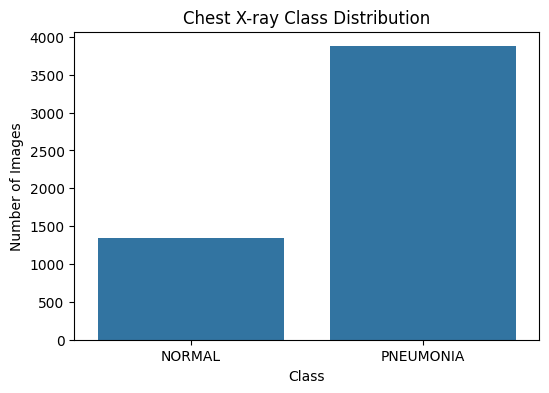

In [5]:
labels = [class_names[label] for _, label in train_dataset]

plt.figure(figsize=(6,4))

sns.countplot(x=labels)

plt.title("Chest X-ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# b)Dataset Visualization

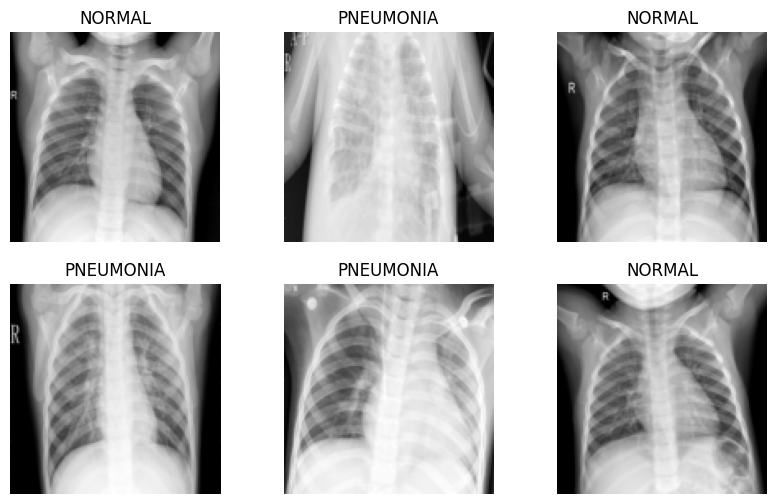

In [6]:
def show_images(loader):

    images, labels = next(iter(loader))

    plt.figure(figsize=(10,6))

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

show_images(train_loader)

# 6.Classical CNN Model

In [7]:
class ClassicalCNN(nn.Module):

    def __init__(self):
        super(ClassicalCNN, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_QUBITS)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x


cnn_model = ClassicalCNN().to(DEVICE)
print(cnn_model)

ClassicalCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


# 7️.Model Training (Classical CNN)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LR)

train_losses = []
train_acc = []

for epoch in range(EPOCHS):

    cnn_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} Loss:{epoch_loss:.4f} Accuracy:{epoch_acc:.2f}%")

Epoch 1/5 Loss:0.2163 Accuracy:91.51%
Epoch 2/5 Loss:0.0947 Accuracy:96.63%
Epoch 3/5 Loss:0.0635 Accuracy:97.68%
Epoch 4/5 Loss:0.0728 Accuracy:97.26%
Epoch 5/5 Loss:0.0494 Accuracy:98.24%


# 8.Model Evaluation

In [9]:
cnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = cnn_model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

cnn_accuracy = 100 * sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print("CNN Accuracy:", cnn_accuracy)

              precision    recall  f1-score   support

      NORMAL       0.94      0.51      0.66       234
   PNEUMONIA       0.77      0.98      0.86       390

    accuracy                           0.80       624
   macro avg       0.85      0.74      0.76       624
weighted avg       0.83      0.80      0.79       624

CNN Accuracy: 80.28846153846153


# 9.Quantum Circuit Definition

In [10]:
dev = qml.device("default.qubit", wires=NUM_QUBITS)

@qml.qnode(dev, interface="torch")

def quantum_circuit(inputs, weights):

    qml.AngleEmbedding(inputs, wires=range(NUM_QUBITS))

    qml.BasicEntanglerLayers(weights, wires=range(NUM_QUBITS))

    return [qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS)]


weight_shapes = {"weights": (3, NUM_QUBITS)}

quantum_layer = qml.qnn.TorchLayer(
    quantum_circuit,
    weight_shapes
)

# 10.Hybrid Quantum Classical Model Architecture

In [11]:
class HybridModel(nn.Module):

    def __init__(self, feature_extractor, quantum_layer, num_classes):

        super(HybridModel, self).__init__()

        self.feature_extractor = feature_extractor
        self.quantum_layer = quantum_layer
        self.classifier = nn.Linear(NUM_QUBITS, num_classes)

    def forward(self, x):

        # Extract CNN features
        x = self.feature_extractor(x)

        # Pass each sample through quantum circuit
        q_out = torch.stack([self.quantum_layer(sample) for sample in x])

        # Final classifier
        x = self.classifier(q_out)

        return x


hybrid_model = HybridModel(cnn_model, quantum_layer, 2).to(DEVICE)

print(hybrid_model)

HybridModel(
  (feature_extractor): ClassicalCNN(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=16384, out_features=128, bias=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=4, bias=True)
    )
  )
  (quantum_layer): <Quantum Torch Layer: func=quantum_circuit>
  (classifier): Linear(in_features=4, out_features=2, bias=True)
)


# 11.Hybrid Model Training

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(hybrid_model.parameters(), lr=LR)

for epoch in range(EPOCHS):

    hybrid_model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = hybrid_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:{running_loss/len(train_loader):.4f}")

Epoch 1 Loss:0.6152
Epoch 2 Loss:0.4788
Epoch 3 Loss:0.3640
Epoch 4 Loss:0.2394
Epoch 5 Loss:0.1659


# 12.Model Evaluation on Test Dataset

In [13]:
hybrid_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = hybrid_model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

hybrid_accuracy = 100 * sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print("Hybrid Accuracy:", hybrid_accuracy)


              precision    recall  f1-score   support

      NORMAL       1.00      0.21      0.34       234
   PNEUMONIA       0.68      1.00      0.81       390

    accuracy                           0.70       624
   macro avg       0.84      0.60      0.57       624
weighted avg       0.80      0.70      0.63       624

Hybrid Accuracy: 70.1923076923077


# 13.Model Comparission

In [14]:
print("Model Comparison")
print("-------------------------")
print(f"Classical CNN Accuracy : {cnn_accuracy:.2f}%")
print(f"Hybrid CNN Accuracy    : {hybrid_accuracy:.2f}%")

Model Comparison
-------------------------
Classical CNN Accuracy : 80.29%
Hybrid CNN Accuracy    : 70.19%


CNN vs Hybrid comparison bar graph

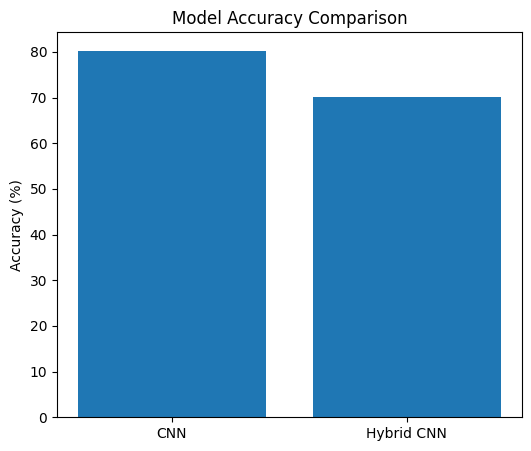

In [15]:
models = ['CNN', 'Hybrid CNN']
accuracies = [cnn_accuracy, hybrid_accuracy]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

# 14.Confusion Matrix Visualization

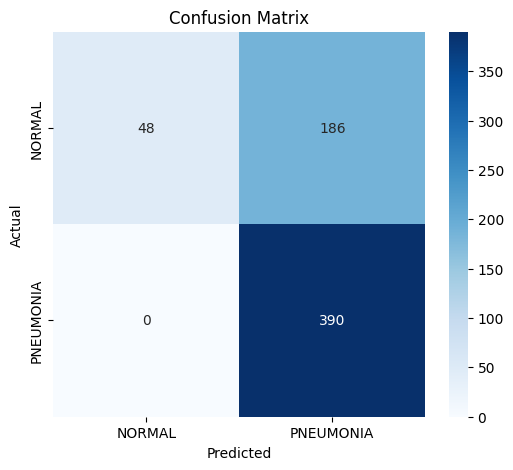

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 15.Training Loss and Accuracy Curves

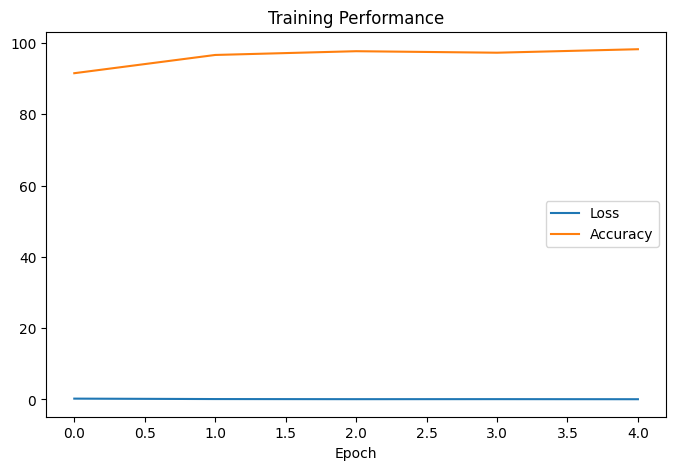

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Loss")
plt.plot(train_acc,label="Accuracy")

plt.title("Training Performance")
plt.xlabel("Epoch")
plt.legend()

plt.show()